In [99]:
import numpy as np
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv');
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [101]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [102]:
# checking null values and negative values in dataset 
print('NULL values:',df.isna().values.any())
print('MISSING values: \n ', df.isnull().sum())
print('DUPLICATE values',df.duplicated().sum())

NULL values: False
MISSING values: 
  Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
DUPLICATE values 0


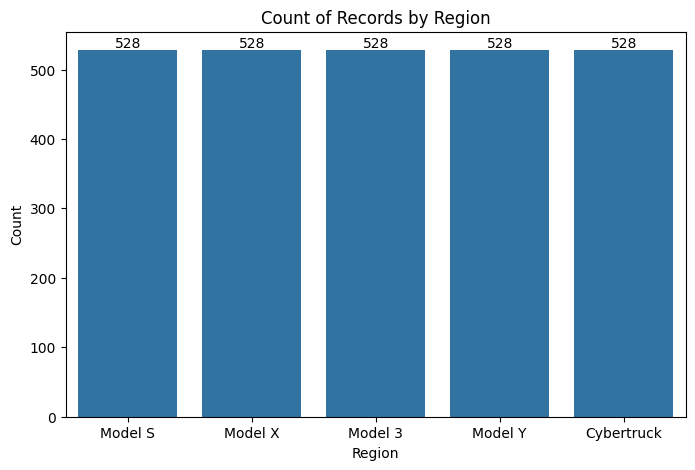

In [103]:
# EDA ( Exploratory Data Analysis)
# Exploratory Data Analysis helps us understand trends, relationships, and patterns within Tesla's deliveries and production data.
# 1. Categorical data plot
# categorical data by region feature.
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Model')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Count of Records by Region")
plt.xlabel("Region")
plt.ylabel("Count")

plt.show()

# we can not use this categorical data so we use average of region ,model by Estimated_Deliveries and avg_prices

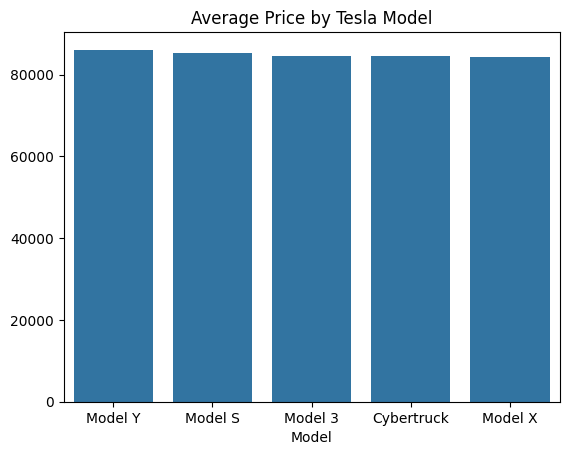

In [104]:
# categorical data average 
avg_price = df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values
)

plt.title("Average Price by Tesla Model")
plt.show()

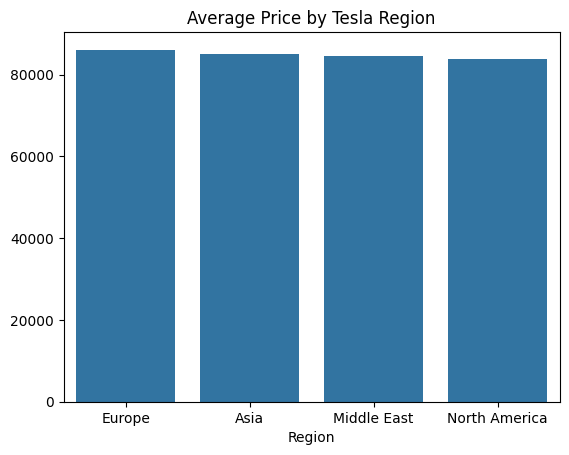

In [105]:
avg_price = df.groupby('Region')['Avg_Price_USD'].mean().sort_values(ascending=False)

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values
)

plt.title("Average Price by Tesla Region")
plt.show()

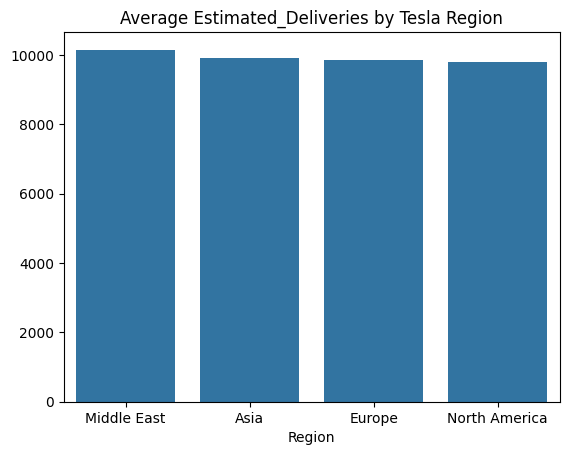

In [106]:
avg_del = df.groupby('Region')['Estimated_Deliveries'].mean().sort_values(ascending=False)

ax = sns.barplot(
    x=avg_del.index,
    y=avg_del.values
)


plt.title("Average Estimated_Deliveries by Tesla Region")
plt.show()

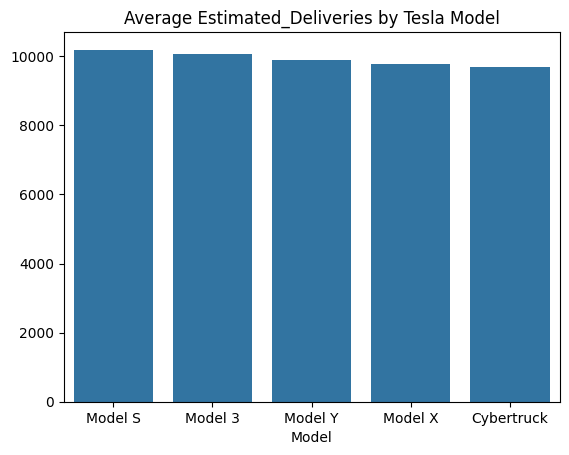

In [107]:
avg_del = df.groupby('Model')['Estimated_Deliveries'].mean().sort_values(ascending=False)

ax = sns.barplot(
    x=avg_del.index,
    y=avg_del.values
)


plt.title("Average Estimated_Deliveries by Tesla Model")
plt.show()

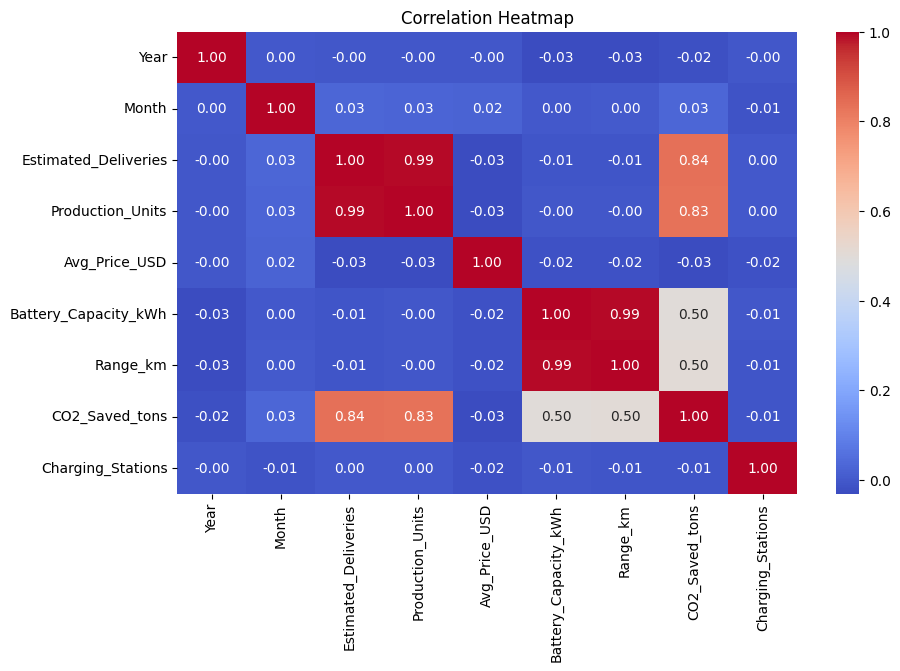

In [108]:
ndf = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    ndf.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

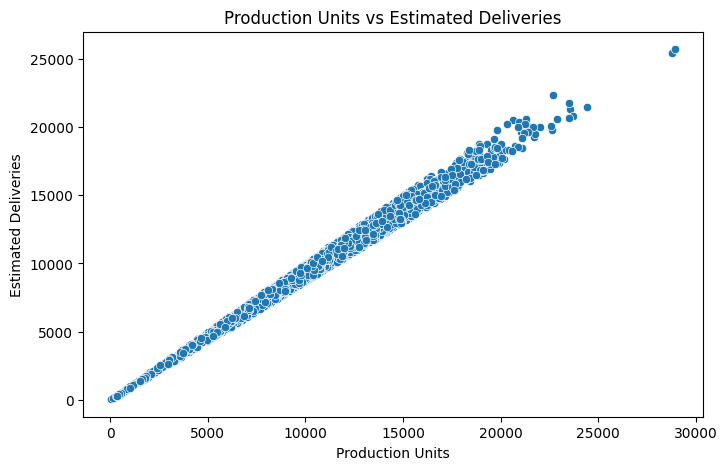

In [109]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["Production_Units"],
    y=df["Estimated_Deliveries"]
)
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

In [110]:
# feature engineering
# 1. onehotencoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler

categorical_cols = ['Region', 'Model', 'Source_Type']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols)
)

df = pd.concat(
    [df.drop(columns=categorical_cols), encoded_df],
    axis=1
)

In [111]:
# 2. Lag Features
df['Prev_Deliveries'] = df['Estimated_Deliveries'].shift(1)

# 3. Rolling mean
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)
# 4. Growth Rate

df['Growth_Rate'] = (
    df['Estimated_Deliveries']
    .pct_change()
)
df.fillna(0, inplace=True)
# 5. date extraction
df["Date"] = pd.to_datetime(
    dict(year=df.Year,
         month=df.Month,
         day=1)
)


In [112]:
# For time-series forecasting, avoid random splitting so we using chronological splitting
# 80% train, 20% test
split_idx = int(len(df) * 0.8)

train = df[:split_idx]
test = df[split_idx:]

X_train = train.drop(['Estimated_Deliveries', 'Date'], axis=1)
y_train = train['Estimated_Deliveries']

X_test = test.drop(['Estimated_Deliveries', 'Date'], axis=1)
y_test = test['Estimated_Deliveries']

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2112
Test size: 528


In [113]:
numerical_cols = [
    'Avg_Price_USD',
    'Production_Units',
    'Prev_Deliveries',
    'Rolling_Mean_3',
    'Growth_Rate'
]

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [114]:
print(df['Estimated_Deliveries'].describe())

count     2640.000000
mean      9922.199621
std       3935.950093
min         48.000000
25%       7292.000000
50%       9857.000000
75%      12510.250000
max      25704.000000
Name: Estimated_Deliveries, dtype: float64


In [115]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

print("Model Comparison\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{name}")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print("-" * 40)

Model Comparison

Linear Regression
R² Score : 0.9907
MAE      : 310.98
RMSE     : 377.45
----------------------------------------
Ridge Regression
R² Score : 0.9907
MAE      : 311.08
RMSE     : 377.67
----------------------------------------
Lasso Regression
R² Score : 0.9907
MAE      : 310.71
RMSE     : 377.05
----------------------------------------
Random Forest
R² Score : 0.9905
MAE      : 299.21
RMSE     : 381.04
----------------------------------------


In [116]:
# cross validation

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=tscv,
    scoring='r2'
)

print("Time Series CV Scores:", scores)
print("Mean CV Score:", scores.mean())

Time Series CV Scores: [0.98525926 0.98718518 0.98578167 0.98656291 0.98980804]
Mean CV Score: 0.9869194104977744


In [117]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base Model
rf = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best Model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross Validation Score:
0.9869818609172057


In [118]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [119]:
y_pred = best_model.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation Results")
print("-" * 30)
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

Model Evaluation Results
------------------------------
R² Score : 0.9905
MAE      : 300.21
RMSE     : 382.19


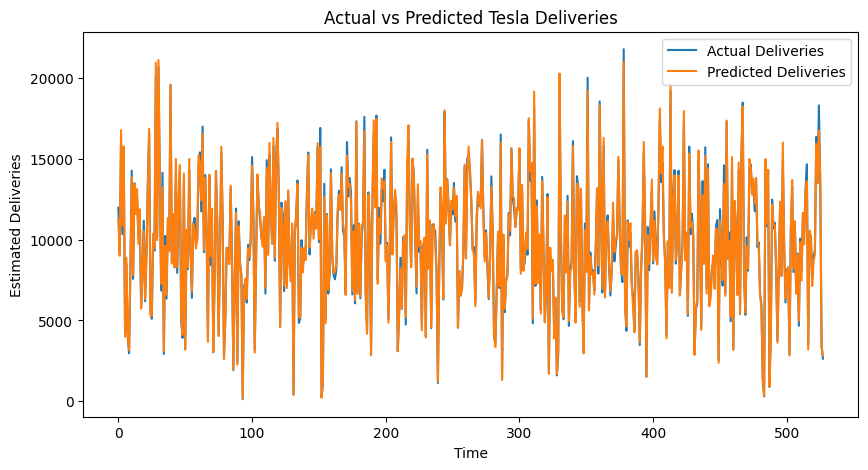

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label="Actual Deliveries"
)

plt.plot(
    y_pred,
    label="Predicted Deliveries"
)

plt.title("Actual vs Predicted Tesla Deliveries")
plt.xlabel("Time")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

In [121]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", result[0])
print("P-Value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
P-Value: 0.0
Series is Stationary


In [122]:
# ==========================
# Future Forecast
# ==========================

forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

forecast_df

,Actual,Predicted
0,11974,11224.790000
1,9189,9002.066667
2,15956,16764.646667
3,10336,10888.183333
4,15152,15764.803333
5,4224,3999.856667
6,8475,8878.680000
7,4093,3860.233333
8,2972,3151.410000
9,8208,8168.570000


In [126]:
# Use last available row
future_row = X_test.iloc[[-1]].copy()

# Predict next month
next_month_prediction = best_model.predict(future_row)[0]

print(f"Predicted Next Month Deliveries: {next_month_prediction:,.0f}")

Predicted Next Month Deliveries: 2,823


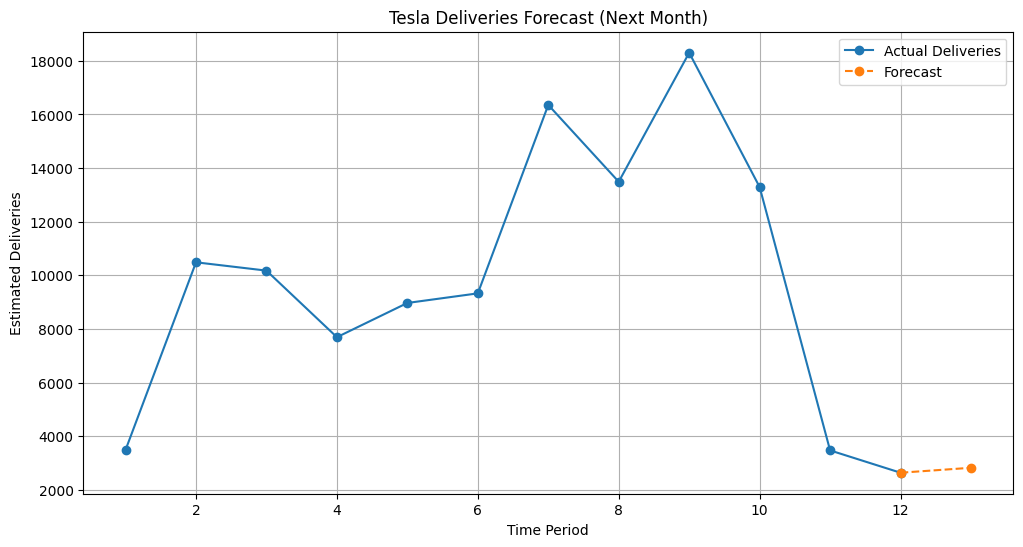

In [127]:
import matplotlib.pyplot as plt

# Last 12 actual values
actual_values = y_test.tail(12).values

# Create forecast series
forecast_values = list(actual_values)
forecast_values.append(next_month_prediction)

# Labels
months = list(range(1, 13))
months.append(13)

plt.figure(figsize=(12,6))

plt.plot(
    months[:-1],
    actual_values,
    marker='o',
    label='Actual Deliveries'
)

plt.plot(
    [months[-2], months[-1]],
    [actual_values[-1], next_month_prediction],
    marker='o',
    linestyle='--',
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast (Next Month)")
plt.xlabel("Time Period")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()